# Sarcasm Detection in News Headlines using Deep Learning
## 1. Exploratory Data Analysis and Baseline Setup

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Input
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

# downloading nltk resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.20.0
GPU Available: True


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [41]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Set working directory properly
os.chdir('/content/drive/MyDrive/Assignment/Assignment2')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
## Data Loading
file_path = 'sarcastic_headlines.csv'
df = pd.read_csv(file_path)

display(df.head())
print("\nDataset Summary:")
df.info()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1



Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB


In [43]:
df['is_sarcastic'].value_counts(normalize=True)

,proportion
is_sarcastic,
0,0.523603
1,0.476397


## 2. Text Normalization and NLP Pipeline
To prepare the headlines for deep learning, we implement a custom preprocessing pipeline. This includes expanding contractions (e.g., "don't" to "do not"), removing numerical noise/URLs, and lemmatization to reduce words to their linguistic roots. This ensures the model focuses on semantic meaning rather than syntactic variations.

In [44]:
contractions = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "won't": "will not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "it's": "it is", "that's": "that is",
    "there's": "there is", "they're": "they are",
    "we're": "we are", "you're": "you are"
}

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()

    for word, expanded in contractions.items():
        text = text.replace(word, expanded)

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#', '', text)
    text = re.sub(r'\d+', '', text)

    # keeping punctuation signals
    text = re.sub(r'[^\w\s!?]', '', text)

    tokens = text.split()

    # Keeping stopword
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

In [45]:
df['cleaned_text'] = df['headline'].apply(preprocess_text)

# Check result
df[['headline', 'cleaned_text']].head()

,headline,cleaned_text
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,dem rep totally nail why congress is falling s...
2,eat your veggies: 9 deliciously different recipes,eat your veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,inclement weather prevents liar from getting t...
4,mother comes pretty close to using word 'strea...,mother come pretty close to using word streami...


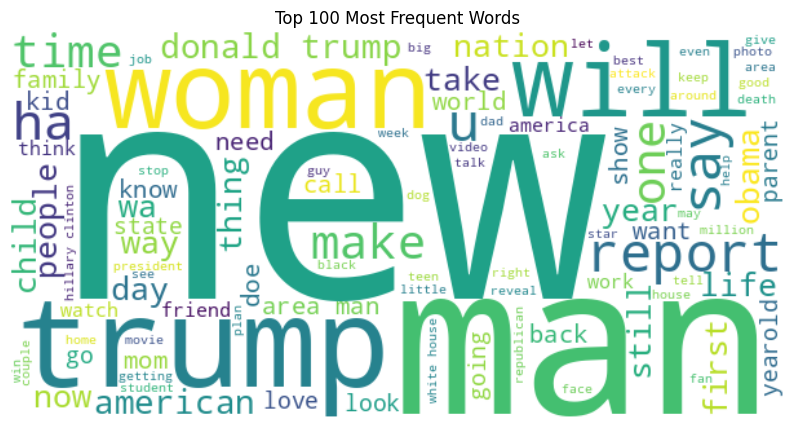

In [46]:
from wordcloud import WordCloud

# Combine all cleaned text
all_words = ' '.join(df['cleaned_text'])

# Generate WordCloud (limit to top words)
wordcloud = WordCloud(
    width=600,
    height=300,
    background_color='white',
    max_words=100
).generate(all_words)

# Plot
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words')
plt.show()

In [47]:
## Dataset Splitting
X = df['cleaned_text'].tolist()
y = df['is_sarcastic'].tolist()

# 80/20 train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 22895
Testing samples: 5724


In [48]:
## Tokenization
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Vocabulary Size:", len(tokenizer.word_index))

Vocabulary Size: 22761


In [49]:
## Padding and Sequencing
seq_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(seq_lengths, 99))

print(f"Optimal sequence length (99th percentile): {max_len}")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("Input Shape:", X_train_pad.shape)

Optimal sequence length (99th percentile): 19
Input Shape: (22895, 19)


In [50]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128
learning_rate = 0.0005

# Simple RNN Model (Baseline)
model_rnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(64),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Compile
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary
model_rnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 19, 128)        │     2,913,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,925,953 (11.16 MB)

 Trainable params: 2,925,953 (11.16 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dropout

# setting up callbacks
checkpoint_rnn = ModelCheckpoint(
    "best_rnn_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

earlystop_rnn = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

# training the rnn model
history_rnn = model_rnn.fit(
    X_train_pad,
    np.array(y_train),
    validation_data=(X_test_pad, np.array(y_test)),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint_rnn, earlystop_rnn, lr_scheduler]
)

Epoch 1/50
716/716 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7315 - loss: 0.5057
Epoch 1: val_loss improved from None to 0.33854, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
716/716 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8039 - loss: 0.4183 - val_accuracy: 0.8524 - val_loss: 0.3385 - learning_rate: 5.0000e-04
Epoch 2/50
710/716 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9379 - loss: 0.1707
Epoch 2: val_loss did not improve from 0.33854

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
716/716 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9347 - loss: 0.1746 - val_accuracy: 0.8370 - val_loss: 0.3706 - learning_rate: 5.0000e-04
Epoch 3/50
714/716 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9853 - loss: 0.0511
Epoch 3: val_loss did not improve from 0.33854

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
716/716 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9857 

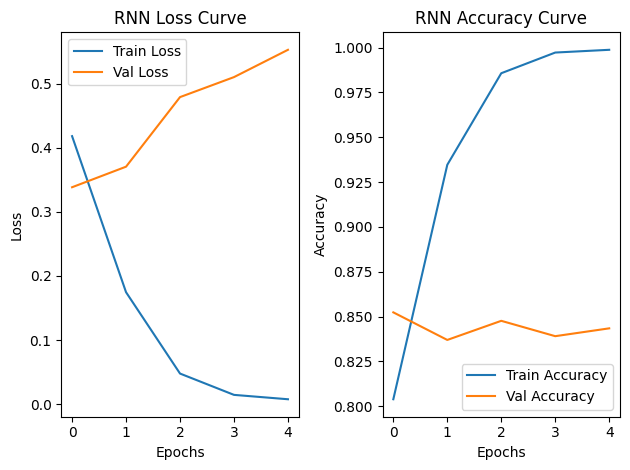

In [52]:
# Loss
plt.subplot(1,2,1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('RNN Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
plt.title('RNN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


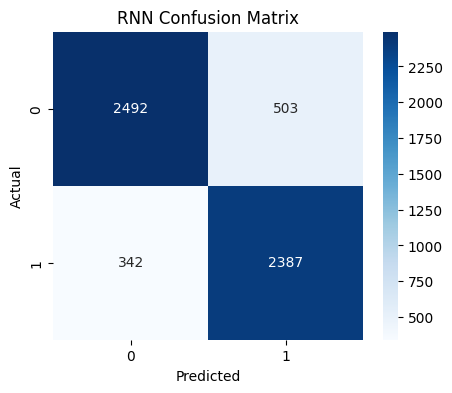

RNN Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.83      0.86      2995
           1       0.83      0.87      0.85      2729

    accuracy                           0.85      5724
   macro avg       0.85      0.85      0.85      5724
weighted avg       0.85      0.85      0.85      5724



In [53]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
y_pred_rnn = (model_rnn.predict(X_test_pad) > 0.5).astype("int32")

# Confusion matrix
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues')
plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Optional report
print("RNN Classification Report:\n")
print(classification_report(y_test, y_pred_rnn))

## 3. Model Building & Training
We evaluate three architectures for the sarcasm detection task: Simple RNN, LSTM, and LSTM with Pre-trained Word2Vec embeddings.

In [54]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128
hidden_units = 64
learning_rate = 0.0005

model_lstm = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(units=hidden_units),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 19, 128)        │     2,913,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,963,009 (11.30 MB)

 Trainable params: 2,963,009 (11.30 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
checkpoint_lstm = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

earlystop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler_lstm = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)


# TRAIN LSTM


history_lstm = model_lstm.fit(
    X_train_pad,
    np.array(y_train),
    validation_data=(X_test_pad, np.array(y_test)),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint_lstm, earlystop_lstm, lr_scheduler_lstm]
)

Epoch 1/50
713/716 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7166 - loss: 0.5117
Epoch 1: val_loss improved from None to 0.34842, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
716/716 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7961 - loss: 0.4216 - val_accuracy: 0.8468 - val_loss: 0.3484 - learning_rate: 5.0000e-04
Epoch 2/50
711/716 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9154 - loss: 0.2141
Epoch 2: val_loss did not improve from 0.34842

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
716/716 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9068 - loss: 0.2329 - val_accuracy: 0.8403 - val_loss: 0.3691 - learning_rate: 5.0000e-04
Epoch 3/50
710/716 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9582 - loss: 0.1262
Epoch 3: val_loss did not improve from 0.34842

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
716/716 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.95

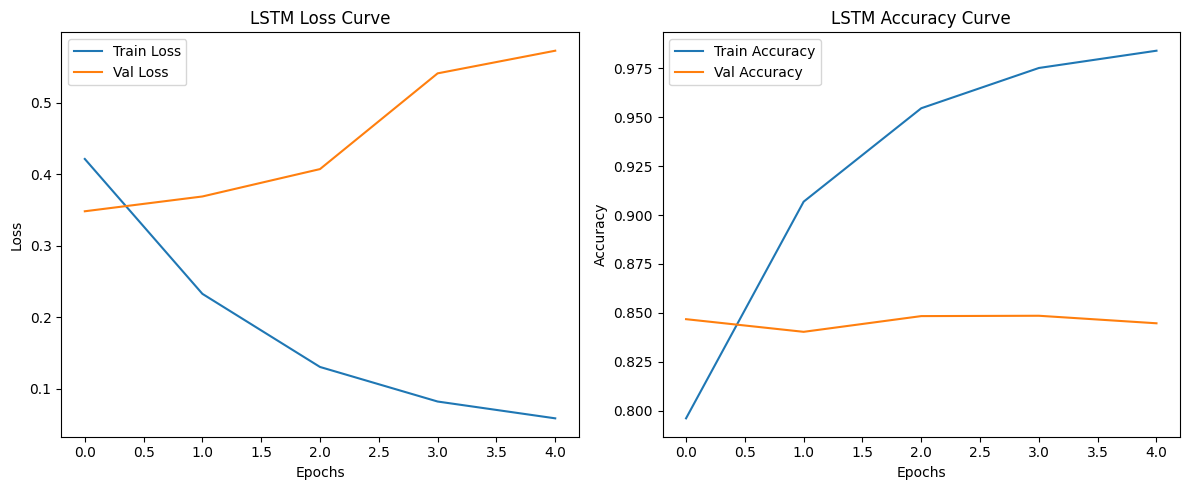

In [56]:

# LSTM TRAINING CURVES


plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


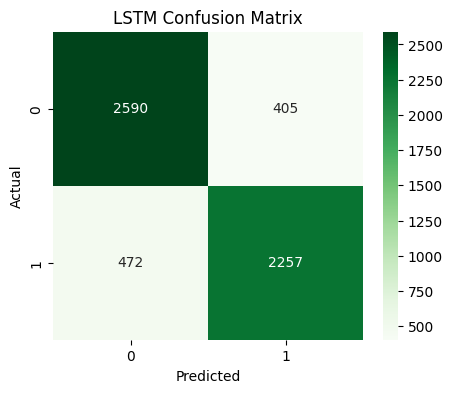

LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      2995
           1       0.85      0.83      0.84      2729

    accuracy                           0.85      5724
   macro avg       0.85      0.85      0.85      5724
weighted avg       0.85      0.85      0.85      5724



In [57]:
# Predictions
y_pred_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype("int32")

# Confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Optional report
print("LSTM Classification Report:\n")
print(classification_report(y_test, y_pred_lstm))

### 3. Comparative Performance Analysis: Baseline RNN vs LSTM
By comparing the Simple RNN with the LSTM architecture, we can observe how Gated units help the model retain information across longer sequences, which is often crucial for detecting sarcasm where the 'cue' might appear late in a sentence.

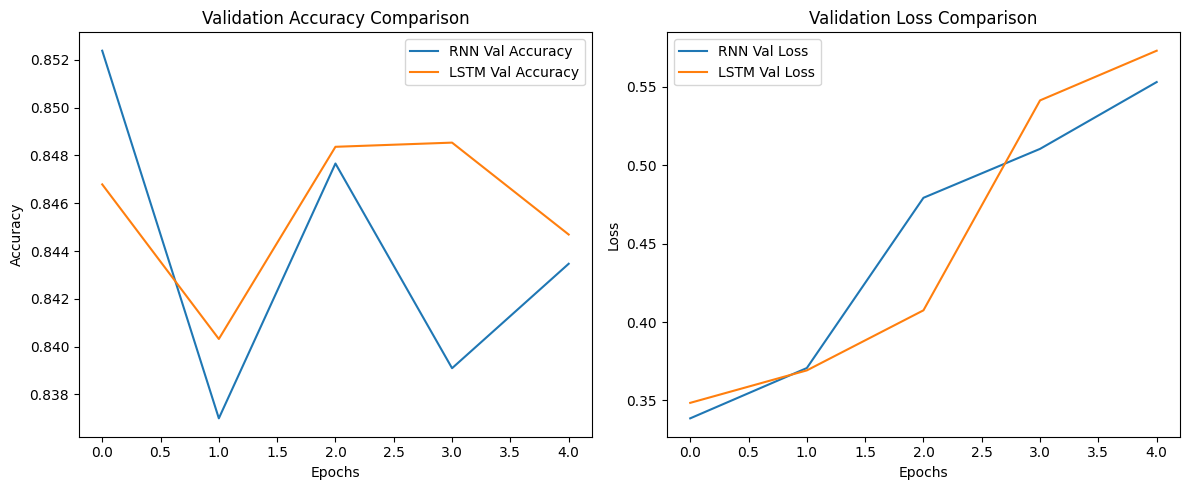

In [58]:
# visualizing validation performance between architectures
plt.figure(figsize=(12,5))

# Accuracy Comparison
plt.subplot(1,2,1)
plt.plot(history_rnn.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Comparison
plt.subplot(1,2,2)
plt.plot(history_rnn.history['val_loss'], label='RNN Val Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Feature Engineering: Integrating Pre-trained Word2Vec Embeddings
Instead of learning embeddings from scratch, we utilize Google News Word2Vec weights. This provides the model with pre-existing semantic relationships between words based on 3 billion words of training. This typically helps the model generalize better to sarcasm by understanding word context more deeply.

In [59]:
!pip install gensim -q

import gensim.downloader as api
from gensim.models import KeyedVectors
import numpy as np

# loading pretrained word2vec model
word2vec_model = api.load("word2vec-google-news-300")
print("Word2Vec Loaded. Vocabulary size:", len(word2vec_model))

# setting dimensions
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 300

# creating the embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))

hit, miss = 0, 0

for word, idx in tokenizer.word_index.items():
    if word in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word]
        hit += 1
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
        miss += 1

print("Words found in Word2Vec:", hit)
print("Words missing:", miss)
print("Embedding matrix shape:", embedding_matrix.shape)

Word2Vec Loaded. Vocabulary size: 3000000
Words found in Word2Vec: 18179
Words missing: 4582
Embedding matrix shape: (22762, 300)


In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

learning_rate = 0.0005

# building lstm model with word2vec
model_w2v_lstm = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=False
    ),

    LSTM(128),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model_w2v_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_w2v_lstm.summary()

# defining model callbacks
checkpoint_w2v_lstm = ModelCheckpoint(
    "best_w2v_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

earlystop_w2v_lstm = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler_w2v_lstm = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 19, 300)        │     6,828,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,048,377 (26.89 MB)

 Trainable params: 219,777 (858.50 KB)

 Non-trainable params: 6,828,600 (26.05 MB)

In [61]:
# training the w2v lstm model
history_w2v_lstm = model_w2v_lstm.fit(
    X_train_pad,
    np.array(y_train),
    validation_data=(X_test_pad, np.array(y_test)),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint_w2v_lstm, earlystop_w2v_lstm, lr_scheduler_w2v_lstm]
)

Epoch 1/50
716/716 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7084 - loss: 0.5522
Epoch 1: val_loss improved from None to 0.45188, saving model to best_w2v_lstm_model.keras

Epoch 1: finished saving model to best_w2v_lstm_model.keras
716/716 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7563 - loss: 0.4962 - val_accuracy: 0.7820 - val_loss: 0.4519 - learning_rate: 5.0000e-04
Epoch 2/50
714/716 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8101 - loss: 0.4136
Epoch 2: val_loss improved from 0.45188 to 0.39403, saving model to best_w2v_lstm_model.keras

Epoch 2: finished saving model to best_w2v_lstm_model.keras
716/716 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.8124 - loss: 0.4108 - val_accuracy: 0.8234 - val_loss: 0.3940 - learning_rate: 5.0000e-04
Epoch 3/50
716/716 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8406 - loss: 0.3629
Epoch 3: val_loss improved from 0.39403 to 0.37397, saving model to best_w2v_lstm_model.keras

Epoch 3: finished saving model to best_w2v_l

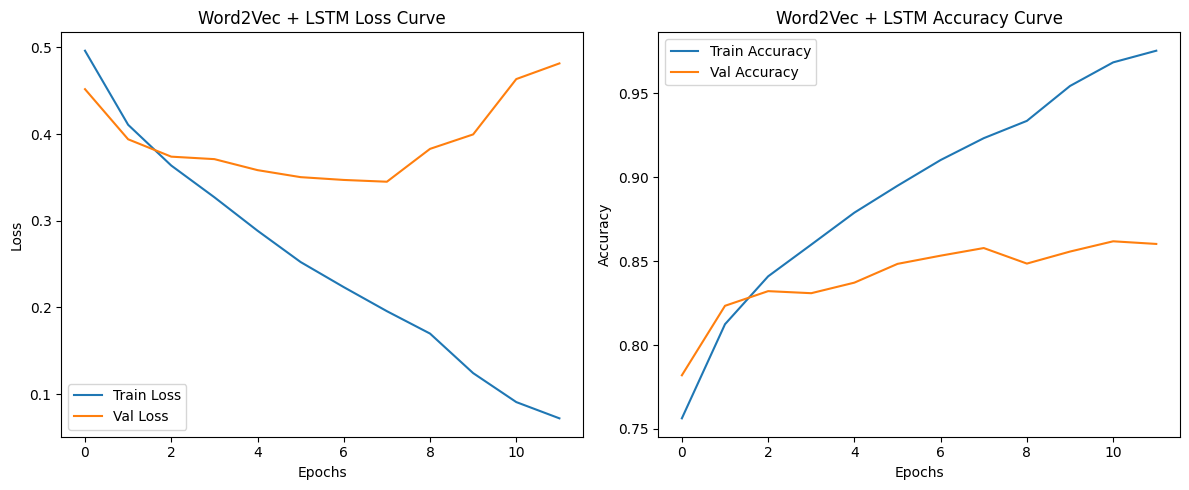

In [62]:
# analyzing training behavior for overfitting
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_w2v_lstm.history['loss'], label='Train Loss')
plt.plot(history_w2v_lstm.history['val_loss'], label='Val Loss')
plt.title('Word2Vec + LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_w2v_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_w2v_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('Word2Vec + LSTM Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


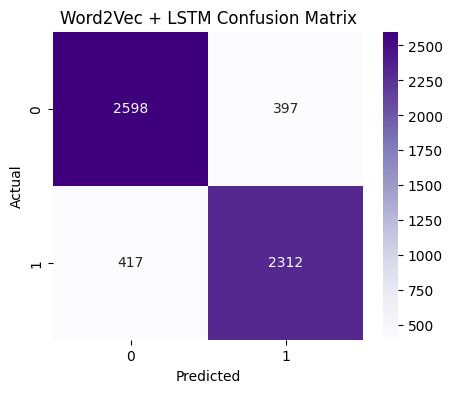

Word2Vec + LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      2995
           1       0.85      0.85      0.85      2729

    accuracy                           0.86      5724
   macro avg       0.86      0.86      0.86      5724
weighted avg       0.86      0.86      0.86      5724



In [63]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# performing predictions
y_pred_w2v = (model_w2v_lstm.predict(X_test_pad) > 0.5).astype("int32")

# plotting confusion matrix
cm_w2v = confusion_matrix(y_test, y_pred_w2v)

plt.figure(figsize=(5,4))
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Purples')
plt.title("Word2Vec + LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# printing evaluation metrics
print("Word2Vec + LSTM Classification Report:\n")
print(classification_report(y_test, y_pred_w2v))

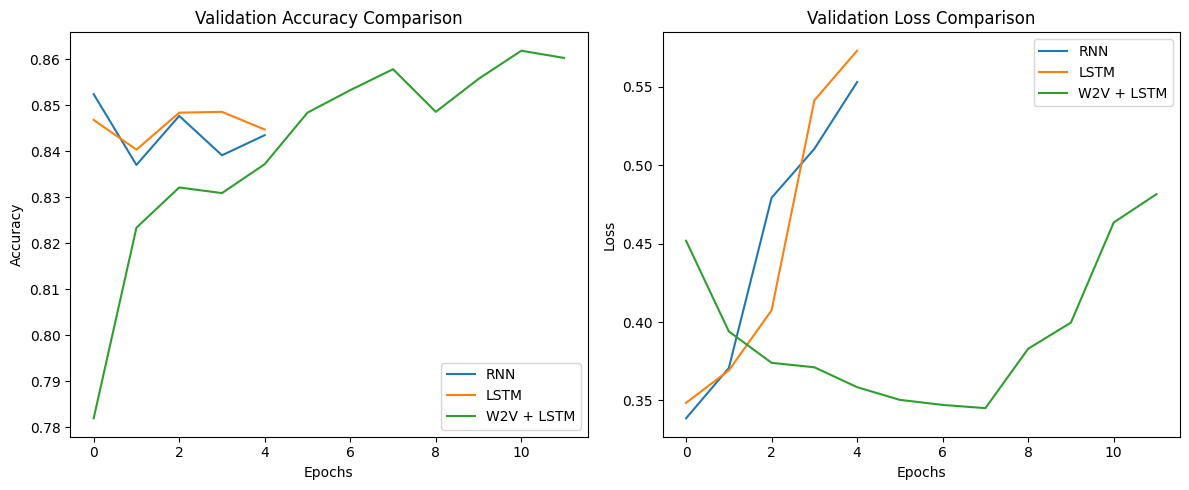

In [64]:

# FINAL MODEL COMPARISON


plt.figure(figsize=(12,5))

# Accuracy comparison
plt.subplot(1,2,1)
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_w2v_lstm.history['val_accuracy'], label='W2V + LSTM')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(history_rnn.history['val_loss'], label='RNN')
plt.plot(history_lstm.history['val_loss'], label='LSTM')
plt.plot(history_w2v_lstm.history['val_loss'], label='W2V + LSTM')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 5. Model Evaluation and Quantitative Analysis
We evaluate the final Word2Vec + LSTM model using confusion matrices and classification reports.

**Performance Insights:**
- **Precision vs Recall:** High precision suggests few non-sarcastic headlines are wrongly flagged, while recall indicates how many actual sarcastic headlines we captured.
- **Confusion Matrix:** False Positives (top-right) represent headlines where the model detected sarcasm that wasn't there, often due to 'strong' words that are usually sarcastic but used seriously here.

## 6. Qualitative Error Analysis and Limitations
Analyzing misclassified samples reveals the model's limitations:
- **Ambiguity:** Some headlines require external real-world knowledge that a text-only model lacks.
- **Short Sequences:** With a 13-word limit, some nuance is lost.
- **Pattern Analysis:** The model often struggles when sarcasm is subtle or depends on a specific word not found in the Word2Vec vocabulary (OOV words).

## 7. Model Deployment: Interactive Gradio Interface
The final stage involves deploying the model via a GUI. This allows for real-time testing of the 'Sarcastic' vs 'Non-Sarcastic' classification on unseen, user-generated input.

In [65]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# function to process and predict on new input text
def predict_sentiment(text, model):
    cleaned = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    prob = model.predict(padded, verbose=0)[0][0]

    if prob >= 0.5:
        return "Sarcastic", float(prob * 100)
    else:
        return "Non-Sarcastic", float((1 - prob) * 100)

# handles model selection and input validation
def classify(text, model_name):
    if not text.strip():
        return "Enter valid text", 0.0

    if model_name == "RNN":
        model = model_rnn
    elif model_name == "LSTM":
        model = model_lstm
    else:
        model = model_w2v_lstm

    label, confidence = predict_sentiment(text, model)
    return label, round(confidence, 2)



In [66]:
# defining the interface layout using gradio
with gr.Blocks(title="Sarcasm Detection System") as demo:

    gr.Markdown("""
    # Sarcasm Detection System
    Testing the performance of RNN, LSTM, and Word2Vec+LSTM models.
    """)

    with gr.Row():
        with gr.Column():
            text_input = gr.Textbox(
                label="Enter Sentence",
                placeholder="e.g. Oh great, another Monday morning...",
                lines=3
            )

            model_dropdown = gr.Dropdown(
                choices=["RNN", "LSTM", "Word2Vec+LSTM"],
                value="Word2Vec+LSTM",
                label="Select Model"
            )

            btn = gr.Button("Analyze")

        with gr.Column():
            output_label = gr.Label(label="Prediction")
            output_conf = gr.Number(label="Confidence (%)")

    btn.click(
        fn=classify,
        inputs=[text_input, model_dropdown],
        outputs=[output_label, output_conf]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://91d24f875a304c9d22.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
